In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None 

import h5py as h5 
from astropy import units as u
from astropy import constants as c
from astropy.cosmology import Planck18 as cosmology

import os
import scipy
from collections import Counter
from collections import defaultdict
import gc

from scipy.interpolate import interp1d
from scipy.stats import norm

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "16",
    "xtick.labelsize": "16",
    "ytick.labelsize": "16",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images

from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))


In [3]:
plot_path = 'pop_plots/'
data_path = 'data_files/'

pop_names = ['notides', 'realistic', 'perfect']
# pop_names = ['notides', 'realistic', 'perfect', 'z77']

pop_labels = {'notides': 'legacy', 'realistic': 'kapil26', 'perfect': 'perfect', 'z77': 'z77'}

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'perfect': colorPalette['green'],
             'z77': colorPalette['orange']}


if not os.path.exists(plot_path):
   os.makedirs(plot_path)
   
pop_dfs = {}

for pop_name in pop_names:
    pop_label = pop_labels[pop_name]
    pop_df = pd.read_csv(data_path + pop_name+'_spin_df.csv') 

    pop_df = pop_df[(pop_df['BBH'] == True)]
    pop_df['t_delay'] = pop_df['Time@DCO'] + pop_df['Coalescence_Time'] 

    any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
    any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
    any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)

    smt = any_rlof * (~any_ce) * (~any_che)


    pop_df['formation_channel'] = 0 # None
    pop_df.loc[smt, 'formation_channel'] = 1 # SMT
    pop_df.loc[any_ce, 'formation_channel'] = 2 # CE
    pop_df.loc[any_che, 'formation_channel'] = 3 # CHE

    pop_df_to_keep = pop_df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Metallicity@ZAMS(1)', 'Mass@DCO(1)', 'Mass@DCO(2)', 'chi_eff', 'chi_eff_orb', 't_delay', 'formation_channel', 'CE_Both', 'a1', 'a2', 'a1_orb', 'a2_orb', 'fallback_1', 'fallback_2', 'iota1', 'iota2', 'SemiMajorAxis@DCO', 'Eccentricity@DCO', 'Merges_Hubble_Time', 'Time@DCO', 'Coalescence_Time']]
    print(pop_df_to_keep['formation_channel'].value_counts())
    pop_dfs[pop_name] = pop_df_to_keep

formation_channel
1    104114
2     24145
3      1276
Name: count, dtype: int64
formation_channel
1    105873
2     24008
3       870
Name: count, dtype: int64
formation_channel
1    108984
2     27379
3      1278
Name: count, dtype: int64


# Calculate Merger Rates using Cosmic Integration

In [46]:
from scipy.stats import norm
from scipy.interpolate import interp1d

def get_z_weights_matlab_style(z_grid, z_min, z_max):
    """
    Exactly replicates the MATLAB 'Metallicity' function logic.
    z_grid: array of redshifts (zlistformation)
    z_min, z_max: the metallicity bounds of your COMPAS simulation
    """
    # 1. SFRD formula
    sfr = 0.01 * (1 + z_grid)**2.77 / (1 + ((1 + z_grid) / 2.9)**4.7)
    
    # 2. Mean Metallicity evolution (using natural log sigma=0.39)
    z_mean = 0.035 * 10**(-0.23 * z_grid)
    sigma = 0.39
    z_mu = np.log(z_mean) - (sigma**2 / 2.0)
    
    # 3. Create the logZ grid for evaluation (MATLAB uses -12 to 0 with step 0.1)
    dlogZ = 0.1
    logZ_vec = np.arange(-12, 0.1, dlogZ) 
    
    # 4. Compute dPdlogZ matrix [len(logZ_vec) x len(z_grid)]
    # Use broadcasting to evaluate the normal PDF
    # (logZ_vec[:, None] - z_mu) creates a 2D grid
    dPdlogZ = (1.0 / (sigma * np.sqrt(2 * np.pi))) * \
              np.exp(-(logZ_vec[:, np.newaxis] - z_mu)**2 / (2 * sigma**2))
    
    # Normalize PDF across the grid
    dPdlogZ /= (np.sum(dPdlogZ, axis=0) * dlogZ)
    
    # 5. Handle Tails (Sweeping probability into the simulation bounds)
    min_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_min))
    max_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_max))
    
    # Add everything below minZ to the first valid bin
    dPdlogZ[min_idx, :] += np.sum(dPdlogZ[:min_idx, :], axis=0)
    # Add everything above maxZ to the last valid bin
    dPdlogZ[max_idx, :] += np.sum(dPdlogZ[max_idx+1:, :], axis=0)
    
    # Zero out the indices outside our simulated range
    dPdlogZ[:min_idx, :] = 0
    dPdlogZ[max_idx+1:, :] = 0
    
    # Re-normalize just to be safe
    dPdlogZ /= (np.sum(dPdlogZ, axis=0) * dlogZ)
    
    # 6. Weight by P_draw (Uniform in log-space)
    z_range_ln = np.log(z_max) - np.log(z_min)
    p_draw_z = 1.0 / z_range_ln
    
    # Final weight matrix [len(logZ_vec) x len(z_grid)]
    z_weight_matrix = dPdlogZ / p_draw_z
    
    return sfr, logZ_vec, z_weight_matrix

# Constants/Inputs
z_merger_grid = np.arange(0, 10.01, 0.01) # dz=0.01 like MATLAB
t_lookback = cosmology.lookback_time(z_merger_grid).to('yr').value # Need your t(z) function

# Pre-calculate lookback-time-to-redshift interpolator
t_to_z = interp1d(t_lookback, z_merger_grid, bounds_error=False, fill_value=np.nan)

# Total simulated mass (Msimulated in MATLAB)
M_simulated = 90e6 # Adjust to your actual simulated mass


In [61]:
pop_rates = {}
pop_rates_per_redshift = {}

for pop_name in pop_names:
    pop_label = pop_labels[pop_name]
    
    df = pop_dfs[pop_name].copy() # Store the processed DataFrame for later use

    # Get weights from function above
    sfr, logZ_vec, z_weight_matrix = get_z_weights_matlab_style(
        z_merger_grid, df['Metallicity@ZAMS(1)'].min(), df['Metallicity@ZAMS(1)'].max()
    )

    # Initialize Rates [N_redshifts x N_binaries]
    rates = np.zeros((len(z_merger_grid), len(df)))


    print(f"Calculating rates for {pop_label} population with {len(df)} binaries...")
    for i in range(len(df)):
        z_binary = df['Metallicity@ZAMS(1)'].values[i]
        t_delay = df['t_delay'].values[i]
        
        # 1. Find the metallicity index in the weight matrix
        z_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_binary))
        
        # 2. Formation lookback time for all possible merger times
        t_form = t_lookback + t_delay
        
        # 3. Valid indices where formation happens within our z_grid
        valid = t_form <= np.max(t_lookback)
        
        if np.any(valid):
            # Find formation redshifts
            z_form = t_to_z(t_form[valid])
            
            # We need to find which index in z_merger_grid corresponds to z_form
            # To match MATLAB's 'transpose(SFR(zFormindex))', we interpolate the weight 
            # specifically for this binary's metallicity across redshifts
            binary_z_weight_func = interp1d(z_merger_grid, z_weight_matrix[z_idx, :], fill_value="extrapolate")
            sfr_func = interp1d(z_merger_grid, sfr, fill_value="extrapolate")
            
            # Calculate the rate for this binary at every merger redshift
            # Rate = SFR(z_form) * Weight(z_form, Z_bin) / M_sim
            bin_rate = (sfr_func(z_form) * binary_z_weight_func(z_form)) / M_simulated
            
            rates[valid, i] = bin_rate
    
    pop_rates[pop_name] = rates.sum(axis=0) # Total rate per binary integrated over redshift
    pop_rates_per_redshift[pop_name] = rates # Rate per redshift

Calculating rates for legacy population with 129535 binaries...
Calculating rates for kapil26 population with 130751 binaries...
Calculating rates for perfect population with 137641 binaries...


# Figure 9

notides
realistic
perfect


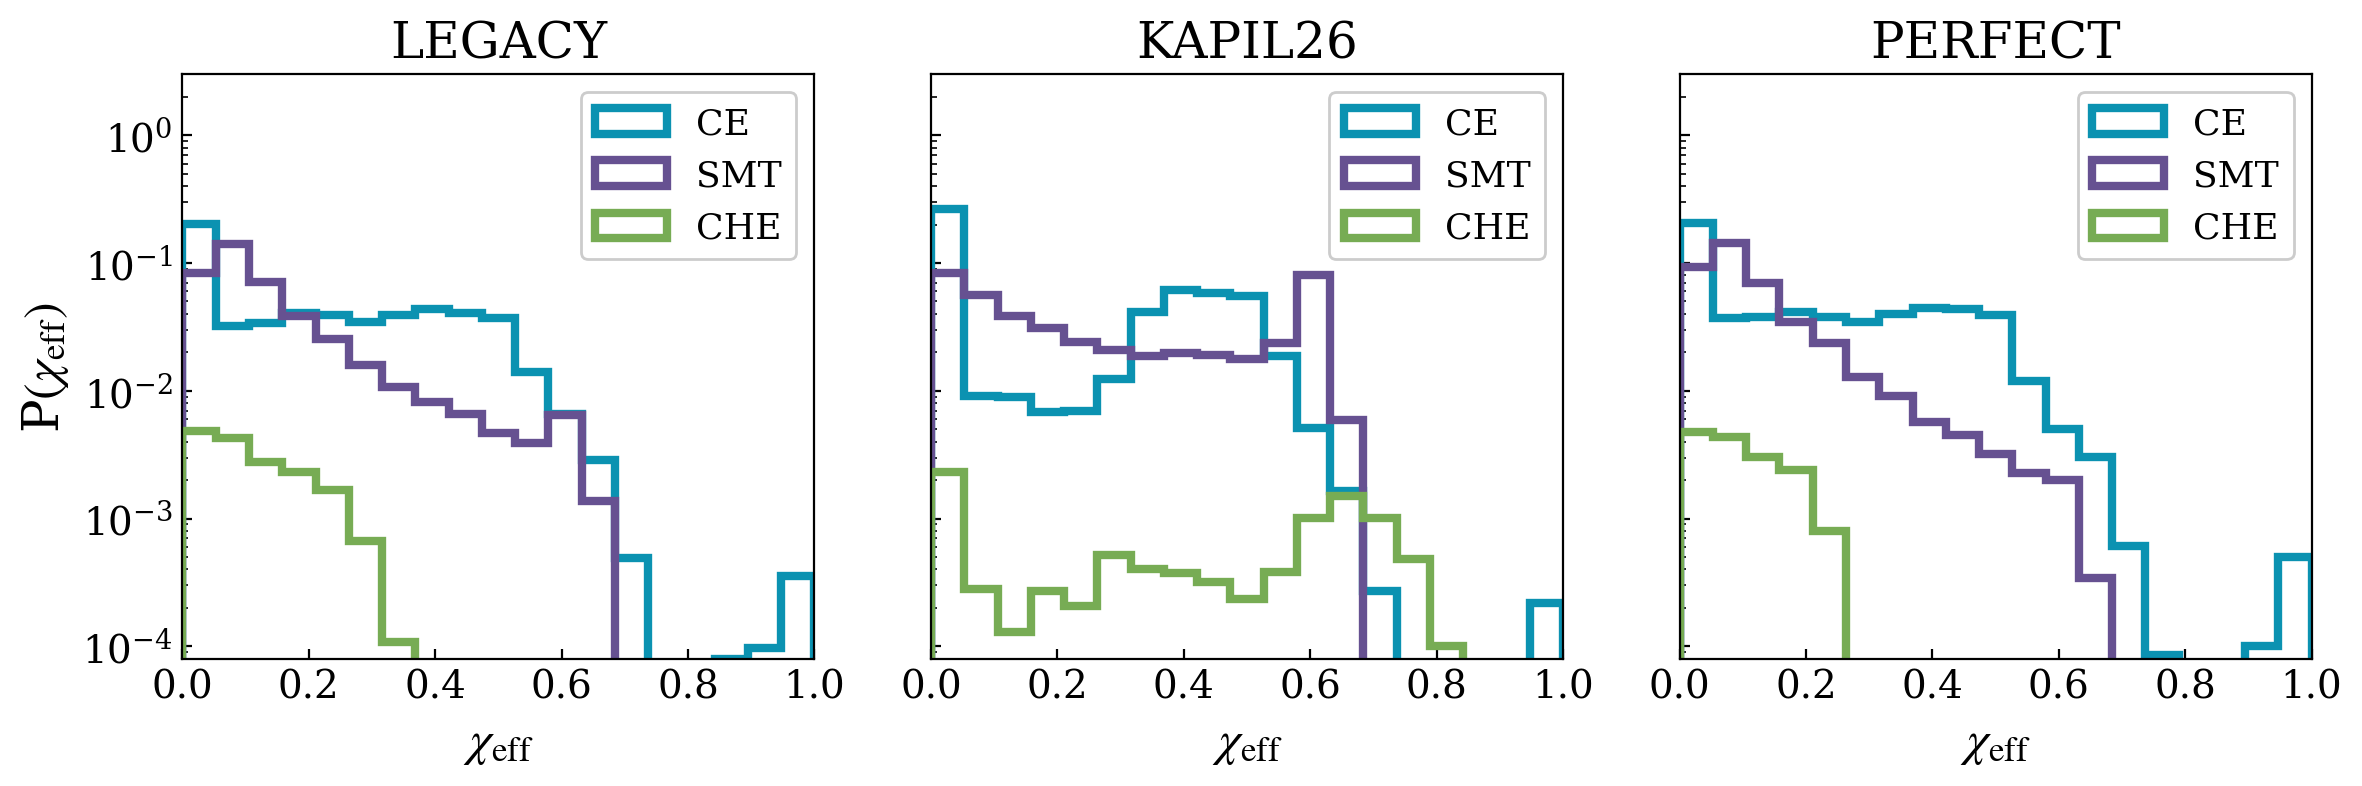

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), sharey=True)

for ax, pop_name in zip(axes, pop_names):
    print(pop_name)
    pop_df = pop_dfs[pop_name]
    merger_mask = (pop_df['Merges_Hubble_Time'] == True)
    pop_df = pop_df[merger_mask]

    total_weights = pop_rates[pop_name][merger_mask]
    weight_norm = np.sum(total_weights)

    channels = {
        'CE':  (pop_df['formation_channel'] == 2, colorPalette['blue']),
        'SMT': (pop_df['formation_channel'] == 1, colorPalette['violet']),
        'CHE': (pop_df['formation_channel'] == 3, colorPalette['green']),
    }

    chi_grid = np.linspace(0, 1, 20)

    for label, (mask, color) in channels.items():
        w = total_weights[mask]

        if pop_name == 'notides' or pop_name == 'perfect':
            chi = pop_df['chi_eff_orb'].values[mask]
        else:
            chi = pop_df['chi_eff'].values[mask]

        if len(chi) > 0 and w.sum() > 0:
            ax.hist(chi, weights=w / weight_norm, bins=chi_grid, density=False, histtype='step', color=color, alpha=1, linewidth=3, label=label)

    ax.set_xlabel(r'$\chi_{\rm eff}$', fontsize=18)
    ax.set_xlim(0.0, 1)
    ax.set_ylim(0.8e-4, 3e0)
    ax.set_xticks(np.arange(0, 1.1, 0.2), minor=True)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=14)
    ax.set_yscale('log')
    ax.set_title(f'{pop_labels[pop_name].upper()}', fontsize=18)

    ax.legend(fontsize=13, loc='upper right')
    # ax.grid()
axes[0].set_ylabel(r'P$(\chi_{\rm eff})$', fontsize=18)
# plt.subplots_adjust(wspace=0.1, hspace=0)
plt.tight_layout()
plt.savefig(plot_path + 'chi_eff_distributions_populations.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Figure 11

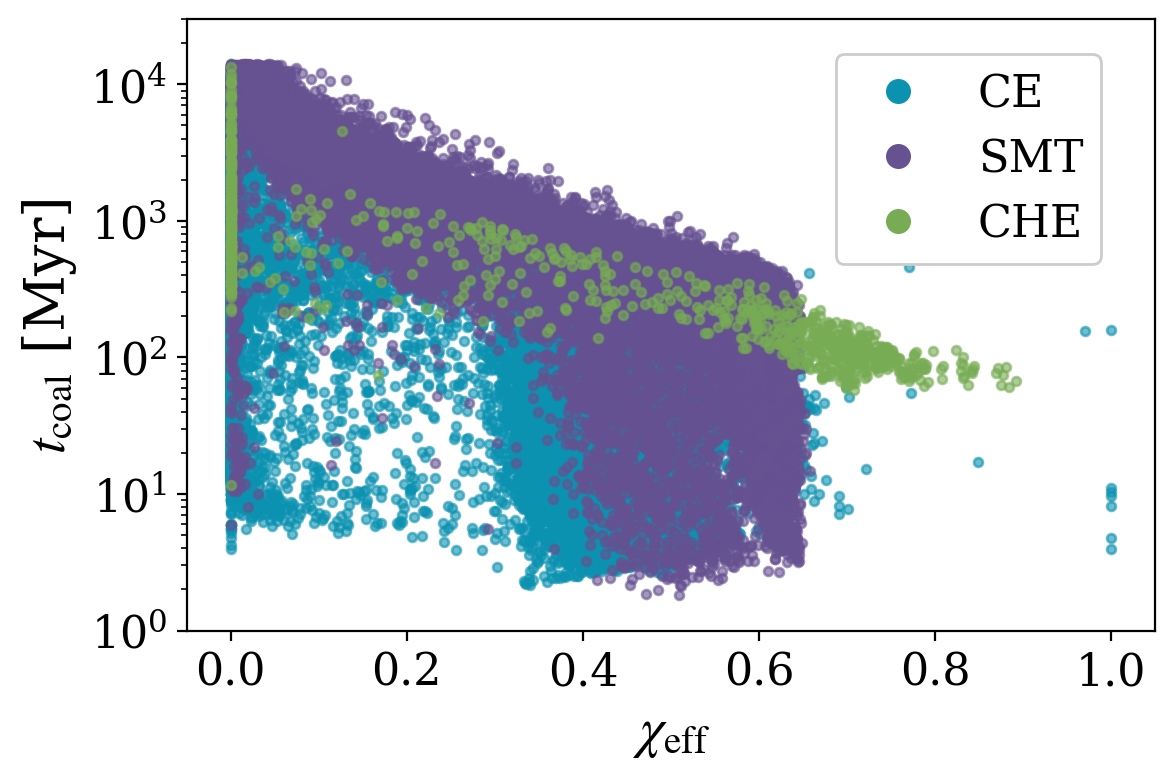

In [12]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize



fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

pop_name = 'realistic'
dco_type='BBH'

pop_spin_df = pop_dfs[pop_name]
pop_spin_df = pop_spin_df[(pop_spin_df["Merges_Hubble_Time"])]
pop_df = pop_spin_df


m1, m2 = pop_df["Mass@DCO(1)"], pop_df["Mass@DCO(2)"]
z1 = pop_df["Metallicity@ZAMS(1)"]
t_coal = pop_df["Coalescence_Time"]
chi_eff_inclination = pop_df['chi_eff']

ce_mask = (pop_df['formation_channel'] == 2)
smt_mask = (pop_df['formation_channel'] == 1)
che_mask = (pop_df['formation_channel'] == 3)

alpha = 0.6
s = 10

######################################

x_vals = chi_eff_inclination
y_vals = t_coal # Myr

ax.scatter(x_vals[ce_mask], y_vals[ce_mask], alpha=alpha, s=s, color=colorPalette['blue'], label='CE', zorder=1)
ax.scatter(x_vals[smt_mask], y_vals[smt_mask], alpha=alpha, s=s, color=colorPalette['violet'], label='SMT', zorder=10)
ax.scatter(x_vals[che_mask], y_vals[che_mask], alpha=alpha, s=s, color=colorPalette['green'], label='CHE', zorder=100)

ax.set_xlabel(r'$\chi_{\rm eff}$', fontsize=20)
ax.set_ylabel(r'$t_{\rm coal}$ [Myr]', fontsize=20)

ax.set_ylim(1e0, 3e4)
ax.set_xlim(-0.05, 1.05)
ax.set_yscale('log')

# ax.grid()

from matplotlib.lines import Line2D

legend_elements = [
Line2D([0], [0], marker='o', color='w', label='CE',
   markerfacecolor=colorPalette['blue'], markersize=10, alpha=1),
Line2D([0], [0], marker='o', color='w', label='SMT',
       markerfacecolor=colorPalette['violet'], markersize=10, alpha=1),
Line2D([0], [0], marker='o', color='w', label='CHE',
       markerfacecolor=colorPalette['green'], markersize=10, alpha=1),
]

ax.legend(handles=legend_elements, fontsize=16, loc=(0.67, 0.6))
plt.tick_params(axis='both', which='major', labelsize=16)


plt.tight_layout()
plt.savefig(plot_path+"chi_eff_tcoal_new.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 12

Overall weighted fraction of mergers with chi_eff >= 0.2: 0.507
Redshift $z=0$: Weighted fraction with chi_eff >= 0.2: 0.219
Redshift $z=1$: Weighted fraction with chi_eff >= 0.2: 0.280
Redshift $z=2$: Weighted fraction with chi_eff >= 0.2: 0.353
Redshift $z=5$: Weighted fraction with chi_eff >= 0.2: 0.572


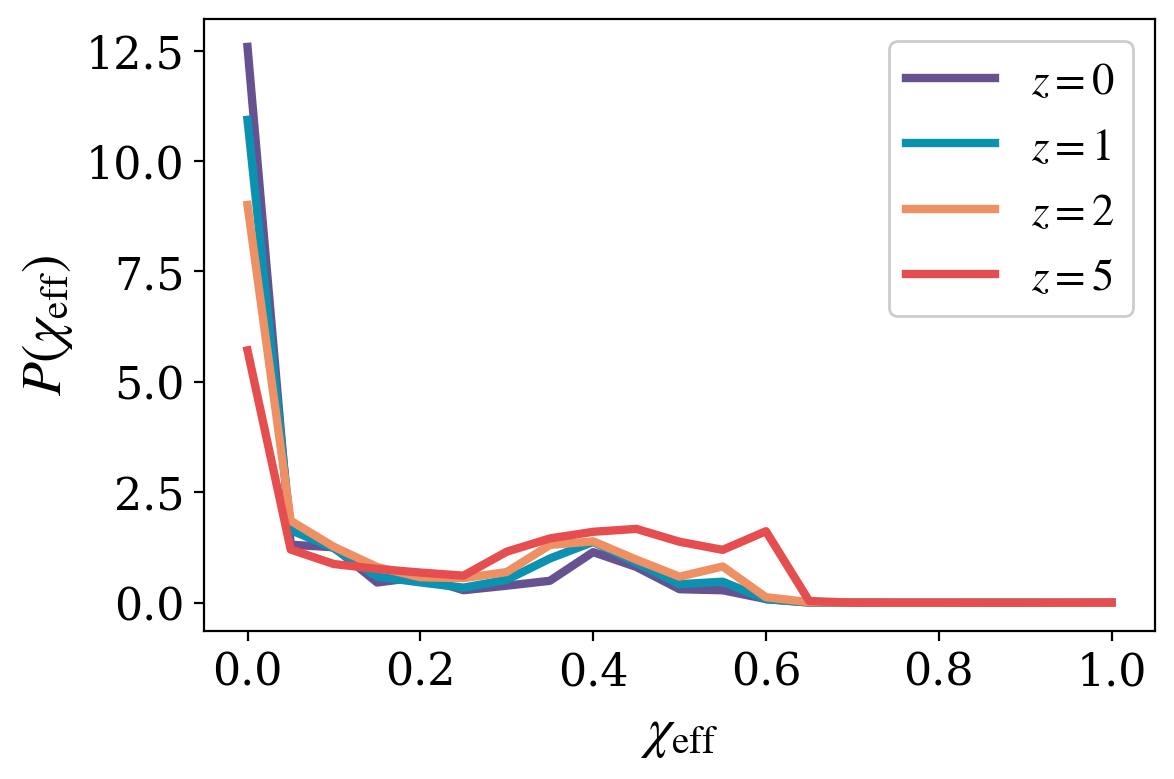

In [62]:
z_list = z_merger_grid

# pop_name = 'notides'
pop_name = 'realistic'
# pop_name = 'perfect'


pop_df = pop_dfs[pop_name]
pop_label = pop_labels[pop_name]

rates = pop_rates_per_redshift[pop_name]

merger_mask = pop_df['Merges_Hubble_Time']
pop_df = pop_df[merger_mask]
merger_rates = rates[:, merger_mask]
chi_eff_mergers = pop_df['chi_eff'].values

print(f"Overall weighted fraction of mergers with chi_eff >= 0.2: {np.sum(merger_rates * (chi_eff_mergers >= 0.2)) / np.sum(merger_rates):.3f}")

# Define chi_eff bins for the histograms
# MATLAB uses floor(chieff*20)+1, which effectively creates bins of width 0.05.
# We create 22 bin edges to get 21 bins matching MATLAB's 0:0.05:1 centers
chi_bins = np.linspace(0, 1.05, 22)
chi_plot_x = np.arange(0, 1.05, 0.05) # For plotting (length 21)

colors = [colorPalette['violet'], colorPalette['blue'], colorPalette['orange'], colorPalette['red']]


def calc_pdf(weights):
    """Helper to calculate normalized PDF matching MATLAB's `/ sum * 20` logic."""
    hist, _ = np.histogram(chi_eff_mergers, bins=chi_bins, weights=weights)
    return (hist / np.sum(hist)) * 20


# --- Figure 12: Intrinsic chi_eff distributions across cosmic time ---
plt.figure(figsize=(6, 4))

z_targets = {0: '$z=0$', 1: '$z=1$', 2: '$z=2$', 5: '$z=5$'}
P_chi_z = []

for i, (z_val, label) in enumerate(z_targets.items()):
    # Find closest redshift index (equivalent to MATLAB's find(zlist>=z, 1))
    z_idx = np.where(z_list >= z_val)[0][0] 
    
    pdf = calc_pdf(merger_rates[z_idx, :])
    P_chi_z.append(pdf)
    plt.plot(chi_plot_x, pdf, lw=3, label=label, color=colors[i])

    print(f"Redshift {label}: Weighted fraction with chi_eff >= 0.2: {np.sum(merger_rates[z_idx, :] * (chi_eff_mergers >= 0.2)) / np.sum(merger_rates[z_idx, :]):.3f}")

plt.xlabel(r'$\chi_{\rm eff}$', fontsize=20)
plt.ylabel(r'$P(\chi_{\rm eff})$', fontsize=20)
plt.legend(fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
# plt.savefig(plot_path + 'chi_eff_redshift_evolution.pdf', dpi=300)
plt.show()

# Figure 13

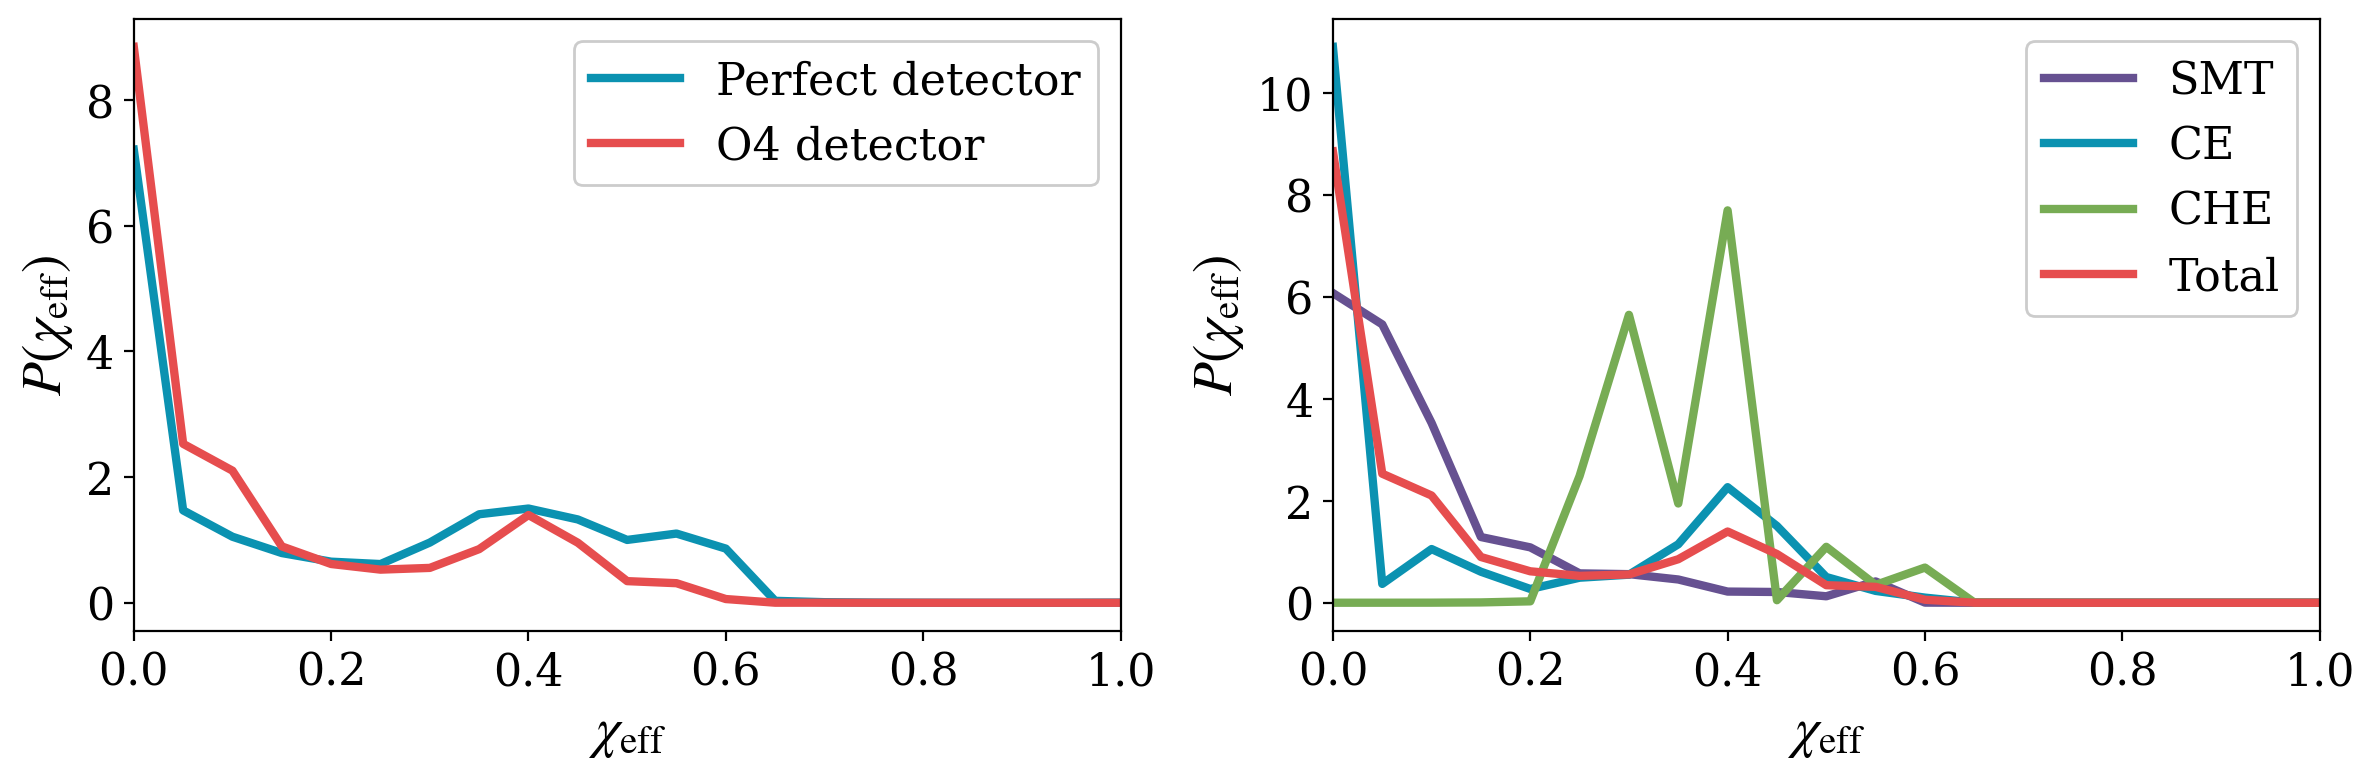

In [4]:
# 1. Load the pre-computed histogram data
data_left = np.loadtxt('data_files/Figure13leftdata.txt')
data_right = np.loadtxt('data_files/Figure13rightdata.txt')

# 2. Define the x-axis grid matching MATLAB's 0:0.05:1
chi_x = np.arange(0, 1.05, 0.05)

# 3. Initialize the figure (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ==========================================
# LEFT PANEL: Perfect vs. O4 Detector
# ==========================================
# Column 0: Perfect, Column 1: O4
ax1.plot(chi_x, data_left[:, 0], lw=3, color=colorPalette['blue'], label='Perfect detector')
ax1.plot(chi_x, data_left[:, 1], lw=3, color=colorPalette['red'], label='O4 detector')

ax1.set_xlabel(r'$\chi_{\rm eff}$', fontsize=20)
ax1.set_ylabel(r'$P(\chi_{\rm eff})$', fontsize=20)
ax1.set_xlim(0, 1.0)
ax1.legend(fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=16)

# ==========================================
# RIGHT PANEL: Formation Channels
# ==========================================
# Column 0: SMT, Column 1: CE, Column 2: CHE, Column 3: Total
ax2.plot(chi_x, data_right[:, 0], lw=3, color=colorPalette['violet'], label='SMT')
ax2.plot(chi_x, data_right[:, 1], lw=3, color=colorPalette['blue'], label='CE')
ax2.plot(chi_x, data_right[:, 2], lw=3, color=colorPalette['green'], label='CHE')
ax2.plot(chi_x, data_right[:, 3], lw=3, color=colorPalette['red'], label='Total')

ax2.set_xlabel(r'$\chi_{\rm eff}$', fontsize=20)
ax2.set_ylabel(r'$P(\chi_{\rm eff})$', fontsize=20)
ax2.set_xlim(0, 1.0)
ax2.legend(fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)

# # Add gridlines if desired (optional but helpful for readability)
# ax1.grid(True, alpha=0.3)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(plot_path + 'chi_eff_det_channel.pdf', dpi=300)
plt.show()

# Other Plots

notides
weighted fraction of binaries with a1 >= 0.95: 0.0004211020680037224
weighted fraction of binaries with a2 >= 0.95: 0.14883911417407533
realistic
weighted fraction of binaries with a1 >= 0.95: 0.00029552639772026
weighted fraction of binaries with a2 >= 0.95: 0.33098334699932064
perfect
weighted fraction of binaries with a1 >= 0.95: 0.0006639339726866292
weighted fraction of binaries with a2 >= 0.95: 0.14440839111660403


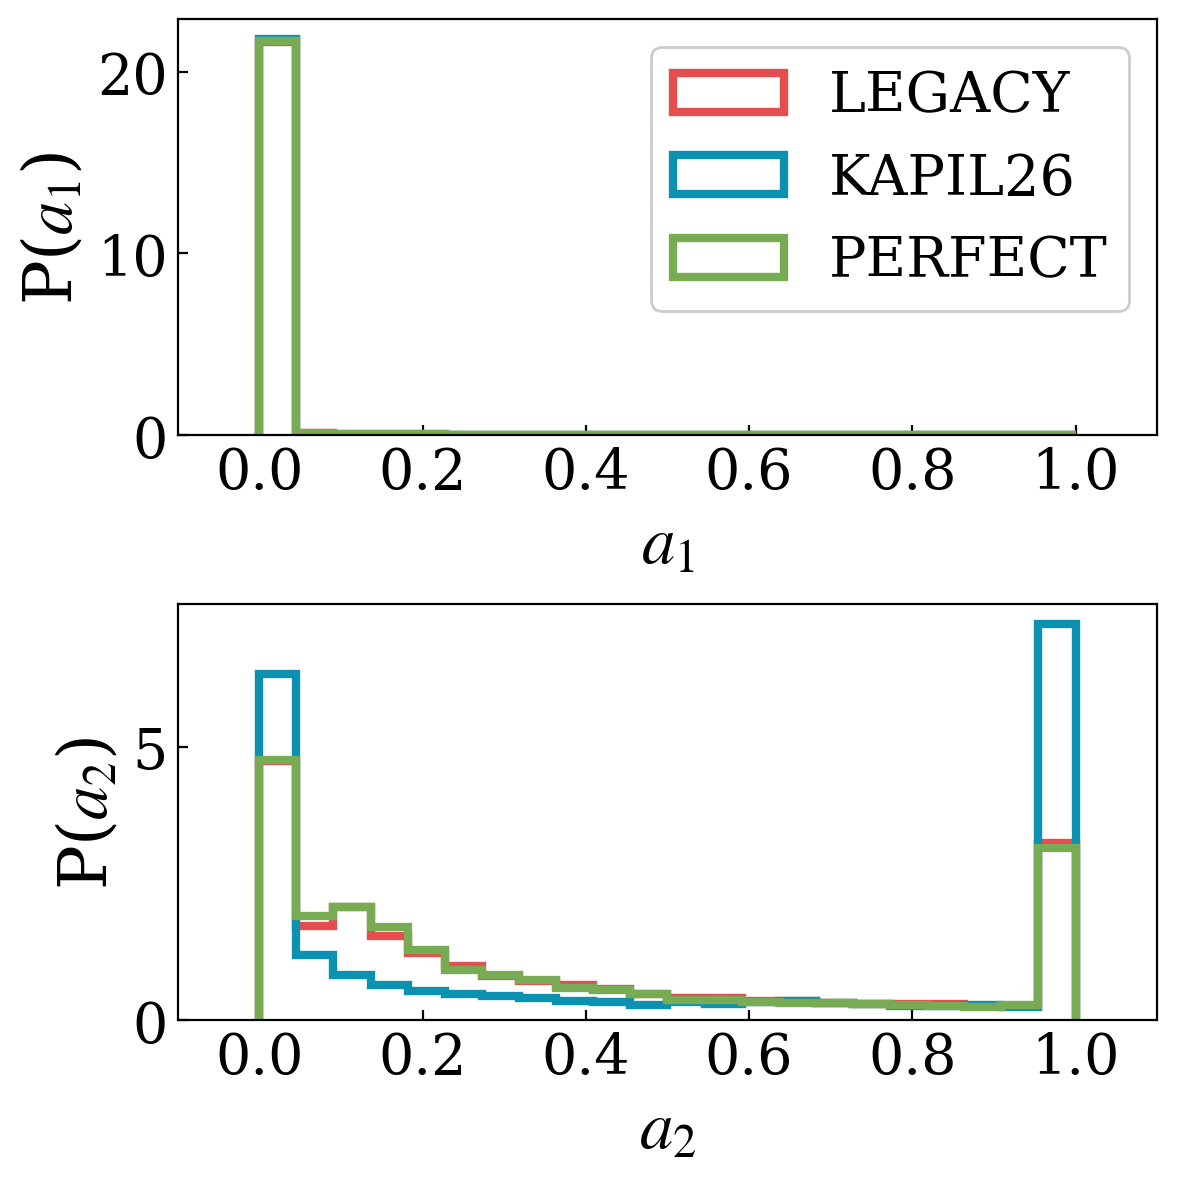

In [ ]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(6,6), sharey=False)

for pop_name in pop_names:
    print(pop_name)
    pop_df = pop_dfs[pop_name]
    merger_mask = (pop_df['Merges_Hubble_Time'] == True)
    pop_df = pop_df[merger_mask]

    total_weights = pop_rates[pop_name][merger_mask]
    weight_norm = np.sum(total_weights)

    a_grid = np.linspace(0, 1, 23)

    w = total_weights
    # mrr_mask = (pop_df['Mass@DCO(1)'] <= pop_df['Mass@DCO(2)'])

    if pop_name == 'notides' or pop_name == 'perfect':
        a1 = pop_df['a1_orb'].values
        a2 = pop_df['a2_orb'].values
    else:
        a1 = pop_df['a1'].values
        a2 = pop_df['a2'].values

    # a1[mrr_mask] = pop_df['a2'].values[mrr_mask]
    # a2[mrr_mask] = pop_df['a1'].values[mrr_mask]


    if len(a1) > 0 and w.sum() > 0:
        axes[0].hist(a1, weights=w / weight_norm, bins=a_grid, density=True, alpha=1, histtype='step', color=pop_colors[pop_name], linewidth=3, label=pop_labels[pop_name].upper())
        axes[1].hist(a2, weights=w / weight_norm, bins=a_grid, density=True, alpha=1, histtype='step', color=pop_colors[pop_name], linewidth=3, label=pop_labels[pop_name].upper())
        print(f"weighted fraction of binaries with a1 >= 0.95: {np.sum(w * (a1 >= 0.95)) / (weight_norm)}")
        print(f"weighted fraction of binaries with a2 >= 0.95: {np.sum(w * (a2 >= 0.95)) / (weight_norm)}")

    
# axes[0].set_title(dco_type, fontsize=20)
axes[0].set_xlabel('$a_{\\rm{1}}$', fontsize=24)
axes[0].set_ylabel('P($a_1$)', fontsize=24)
# axes[0].set_yscale('log')
# axes[0].legend(fontsize=20)

axes[1].set_xlabel('$a_{\\rm{2}}$', fontsize=24)
axes[1].set_ylabel('P($a_2$)', fontsize=24)
# axes[1].set_yscale('log')

axes[0].set_xlim(-0.1,1.1)
axes[1].set_xlim(-0.1,1.1)

# axes[0].set_ylim(0, 23)
# axes[1].set_ylim(0, 23)

axes[0].tick_params(axis='both', direction='in', which='major', labelsize=20)
axes[1].tick_params(axis='both', direction='in', which='major', labelsize=20)

axes[0].set_xticks(ticks=np.linspace(0, 1, 6))
axes[1].set_xticks(ticks=np.linspace(0, 1, 6))

axes[0].legend(fontsize=20)

plt.tight_layout()

plt.savefig(plot_path + 'a_distributions_populations.pdf', dpi=300, bbox_inches='tight')
plt.show()

notides
weighted fraction of binaries with m2 >= m1: 0.518272063817187
weighted fraction of binaries with a1 >= a2: 0.685337120935549

weighted fraction of binaries with a1 >= 0.95: 0.002048158945418793
weighted fraction of binaries with a2 >= 0.95: 0.1009254597360764


realistic
weighted fraction of binaries with m2 >= m1: 0.5216846862657519
weighted fraction of binaries with a1 >= a2: 0.5474158781211192

weighted fraction of binaries with a1 >= 0.95: 0.1465954750136288
weighted fraction of binaries with a2 >= 0.95: 0.33098334699932064


perfect
weighted fraction of binaries with m2 >= m1: 0.49819737668005215
weighted fraction of binaries with a1 >= a2: 0.6663075411583861

weighted fraction of binaries with a1 >= 0.95: 0.06729318116072383
weighted fraction of binaries with a2 >= 0.95: 0.1036864623153868




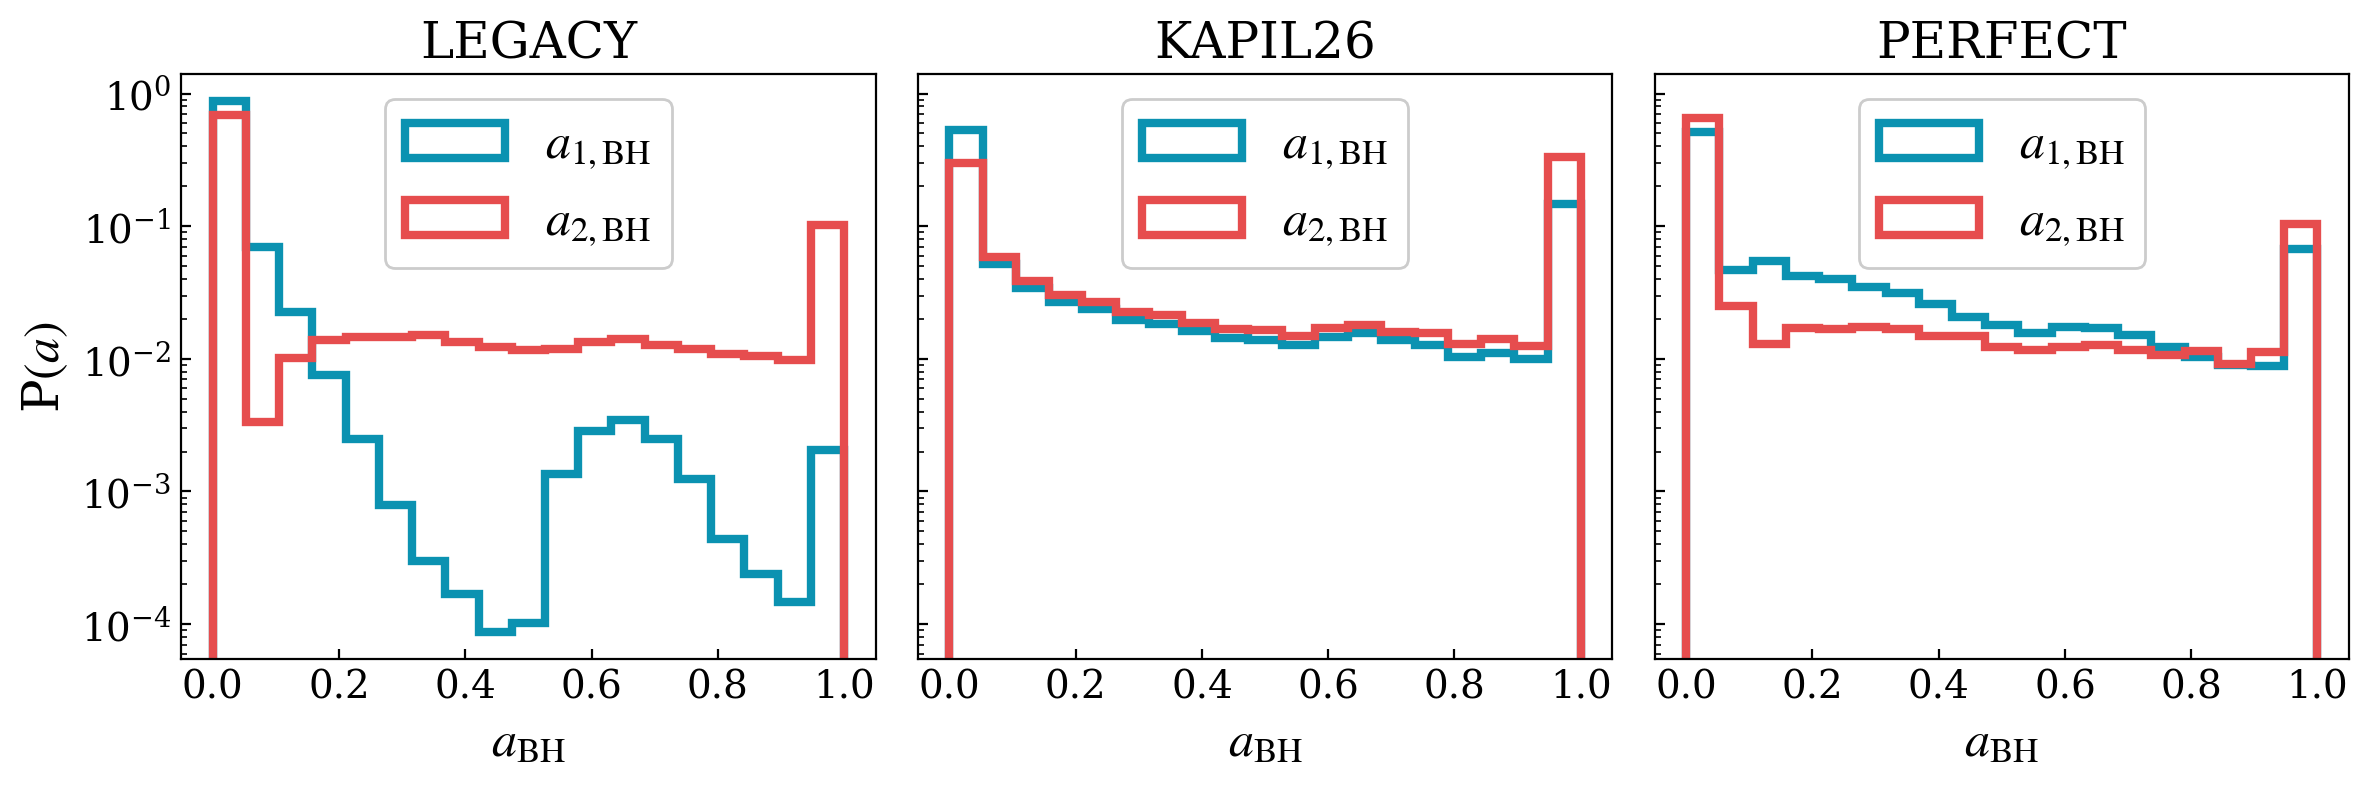

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), sharey=True)

for ax, pop_name in zip(axes, pop_names):
    print(pop_name)
    pop_df = pop_dfs[pop_name]
    merger_mask = (pop_df['Merges_Hubble_Time'] == True)
    pop_df = pop_df[merger_mask]

    total_weights = pop_rates[pop_name][merger_mask]
    weight_norm = np.sum(total_weights)

    a_grid = np.linspace(0, 1, 20)

    w = total_weights
    mrr_mask = (pop_df['Mass@DCO(1)'] <= pop_df['Mass@DCO(2)'])

    if pop_name == 'notides' or pop_name == 'perfect':
        a1 = pop_df['a1_orb'].values
        a2 = pop_df['a2_orb'].values
    else:
        a1 = pop_df['a1'].values
        a2 = pop_df['a2'].values

    a1[mrr_mask] = pop_df['a2'].values[mrr_mask]
    a2[mrr_mask] = pop_df['a1'].values[mrr_mask]


    print(f"weighted fraction of binaries with m2 >= m1: {np.sum(w * ((mrr_mask))) / np.sum(w)}")
    print(f"weighted fraction of binaries with a1 >= a2: {np.sum(w * (a1 >= a2)) / (weight_norm)}")
    print()

    if len(a1) > 0 and w.sum() > 0:
        ax.hist(a1, weights=w / weight_norm, bins=a_grid, density=False, alpha=1, histtype='step', color=colorPalette['blue'], linewidth=3, label=r"$a_{1, \rm{BH}}$")
        ax.hist(a2, weights=w / weight_norm, bins=a_grid, density=False, alpha=1, histtype='step', color=colorPalette['red'], linewidth=3, label=r"$a_{2, \rm{BH}}$")
        print(f"weighted fraction of binaries with a1 >= 0.95: {np.sum(w * (a1 >= 0.95)) / (weight_norm)}")
        print(f"weighted fraction of binaries with a2 >= 0.95: {np.sum(w * (a2 >= 0.95)) / (weight_norm)}")

    print()
    print()

    ax.set_xlabel(r'$a_{\rm BH}$', fontsize=18)
    # ax.set_xlim(0.0, 1)
    # ax.set_ylim(1e-4, 2e0)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=14)
    ax.set_yscale('log')
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_title(f'{pop_labels[pop_name].upper()}', fontsize=18)
    # ax.grid()

    ax.legend(fontsize=18, loc='upper center')

axes[0].set_ylabel(r'P$(a)$', fontsize=18)
# plt.subplots_adjust(wspace=0.1, hspace=0)
plt.tight_layout()

# plt.savefig(plot_path + 'a_bh_distributions_populations.pdf', dpi=300, bbox_inches='tight')
plt.show()

notides
CE
weighted fraction of binaries with m2 >= m1: 0.16307890620502474
SMT
weighted fraction of binaries with m2 >= m1: 0.9802192567074359
CHE
weighted fraction of binaries with m2 >= m1: 0.998470146744047

realistic
CE
weighted fraction of binaries with m2 >= m1: 0.14822865937050964
SMT
weighted fraction of binaries with m2 >= m1: 0.9819548730933606
CHE
weighted fraction of binaries with m2 >= m1: 0.9997430394403694

perfect
CE
weighted fraction of binaries with m2 >= m1: 0.14712072205284216
SMT
weighted fraction of binaries with m2 >= m1: 0.9854665977782833
CHE
weighted fraction of binaries with m2 >= m1: 0.9983061946308731



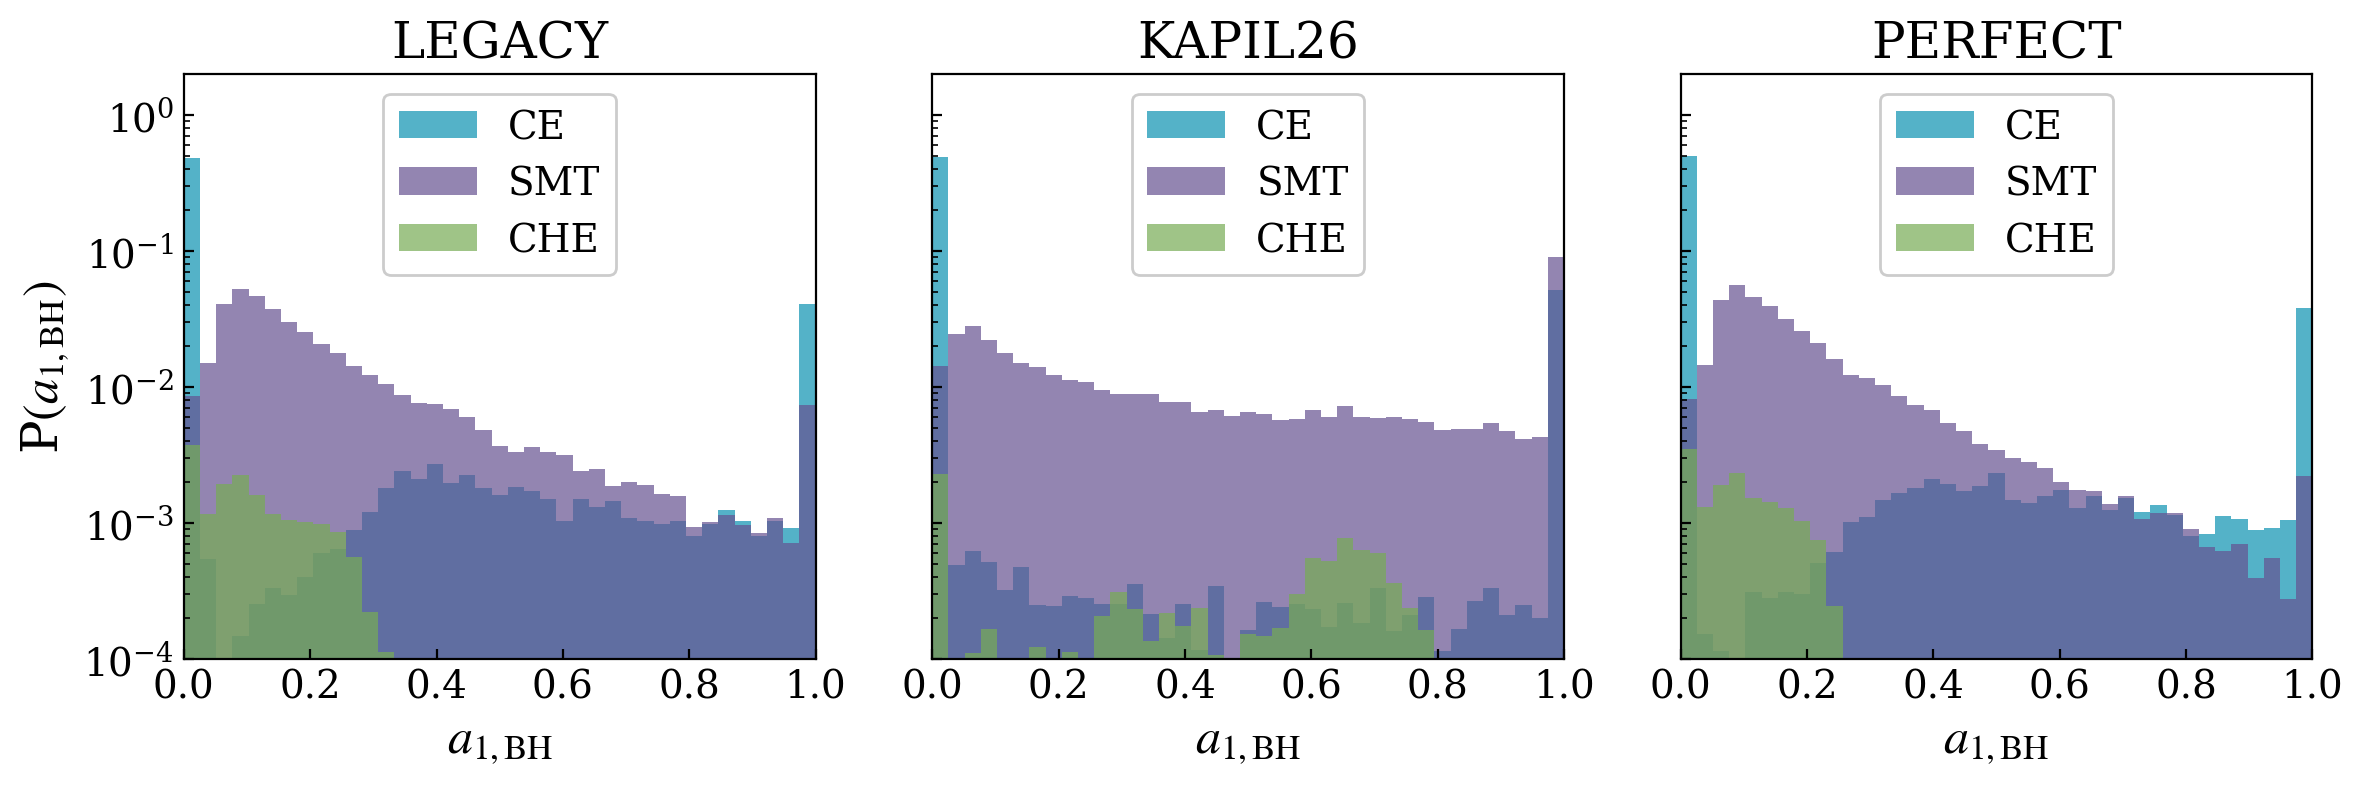

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), sharey=True)

for ax, pop_name in zip(axes, pop_names):
    print(pop_name)
    pop_df = pop_dfs[pop_name]
    merger_mask = (pop_df['Merges_Hubble_Time'] == True)
    pop_df = pop_df[merger_mask]

    total_weights = pop_rates[pop_name][merger_mask]
    weight_norm = np.sum(total_weights)

    if pop_name == 'notides' or pop_name == 'perfect':
        a1_all = pop_df['a1_orb'].values
        a2_all = pop_df['a2_orb'].values
    else:
        a1_all = pop_df['a1'].values
        a2_all = pop_df['a2'].values

    channels = {
        'CE':  (pop_df['formation_channel'] == 2, colorPalette['blue']),
        'SMT': (pop_df['formation_channel'] == 1, colorPalette['violet']),
        'CHE': (pop_df['formation_channel'] == 3, colorPalette['green']),
    }

    a2_grid = np.linspace(0, 1, 40)

    for label, (mask, color) in channels.items():
        w = total_weights[mask]

        a1 = a1_all[mask]
        a2 = a2_all[mask]

        mrr_mask = (pop_df['Mass@DCO(1)'][mask] <= pop_df['Mass@DCO(2)'][mask])
        a1[mrr_mask] = a2[mrr_mask]
        a2[mrr_mask] = a1[mrr_mask]

        print(label)
        print(f"weighted fraction of binaries with m2 >= m1: {np.sum(w * ((mrr_mask))) / np.sum(w)}")

        if len(a1) > 0 and w.sum() > 0:
            ax.hist(a1, weights=w / weight_norm, bins=a2_grid, density=False, color=color, alpha=0.7, linewidth=0.5, label=label)
    print()
    
    ax.set_xlabel(r'$a_{1, \rm{BH}}$', fontsize=18)
    ax.set_xlim(0.0, 1)
    ax.set_ylim(1e-4, 2e0)
    ax.set_xticks(np.arange(0, 1.1, 0.2), minor=True)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=14)
    ax.set_yscale('log')
    
    ax.set_title(f'{pop_labels[pop_name].upper()}', fontsize=18)
    # ax.grid()

    ax.legend(fontsize=14, loc='upper center')

axes[0].set_ylabel(r'P$(a_{1, \rm{BH}})$', fontsize=18)
# plt.subplots_adjust(wspace=0.1, hspace=0)
plt.tight_layout()

plt.show()

## Redshift - Spin Width Correlations

/var/folders/wj/l7fs8hg555n8nzz7myk9cysw0000gn/T/ipykernel_12195/3087223095.py:7: RuntimeWarning: invalid value encountered in divide
  weighted_mean = (rates * chi_eff[np.newaxis, :]).sum(axis=1) / total_rate  # (1001,)


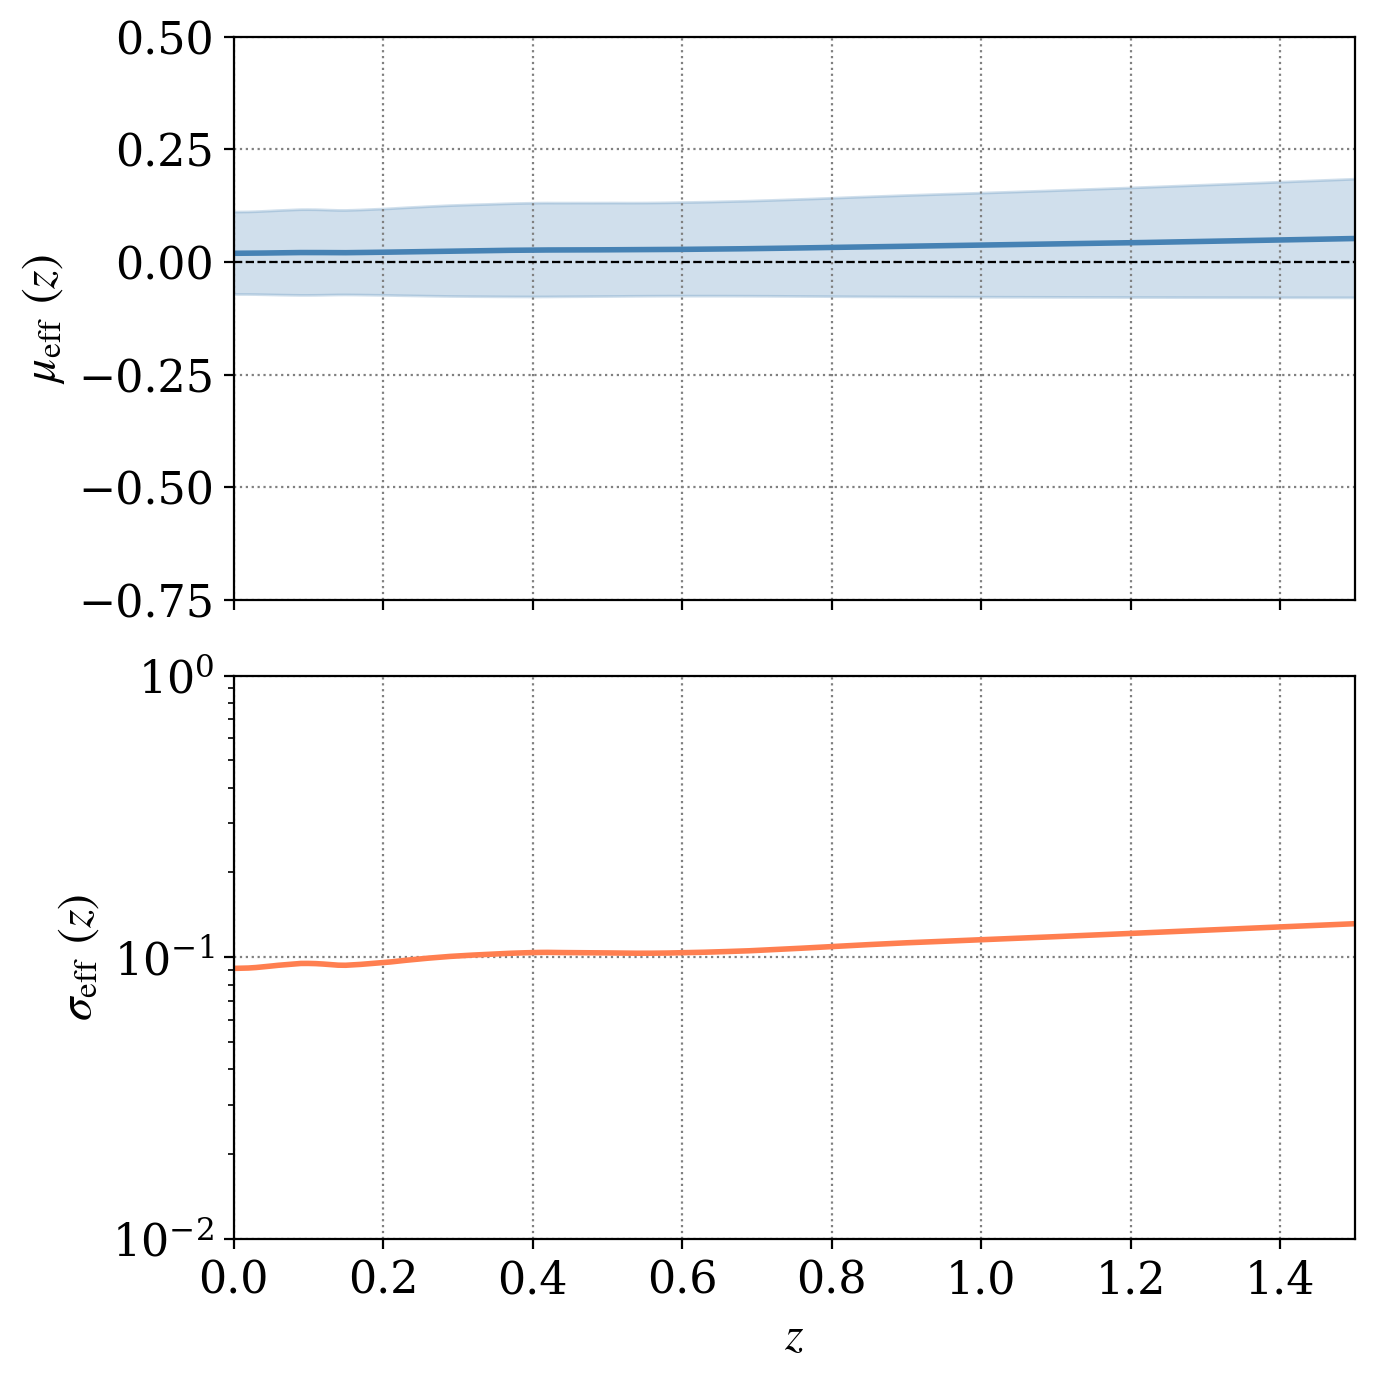

In [26]:

# ── weighted stats vs redshift ────────────────────────────────────────────────
chi_eff = df['chi_eff'].values          # shape (130751,)
# rates shape: (1001, 130751) — axis 0 = redshift bins, axis 1 = binaries

# Weighted mean: sum(w_i * x_i) / sum(w_i)  for each redshift bin
total_rate   = rates.sum(axis=1)                          # (1001,)
weighted_mean = (rates * chi_eff[np.newaxis, :]).sum(axis=1) / total_rate  # (1001,)

# Weighted std: sqrt( sum(w_i * (x_i - mu)^2) / sum(w_i) )
residuals2    = (chi_eff[np.newaxis, :] - weighted_mean[:, np.newaxis])**2  # (1001, 130751)
weighted_std  = np.sqrt((rates * residuals2).sum(axis=1) / total_rate)      # (1001,)

# ── redshift axis ─────────────────────────────────────────────────────────────
# replace with your actual redshift array if you have one
z = np.linspace(0, 10, 1001)   # adjust to match your redshift bins

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# — mean —
axes[0].plot(z, weighted_mean, color='steelblue', lw=2)
axes[0].fill_between(
    z,
    weighted_mean - weighted_std,
    weighted_mean + weighted_std,
    alpha=0.25, color='steelblue'
)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_ylabel(r'$\mu_{\rm eff}$ $(z)$', fontsize=17)
axes[0].grid()
axes[0].set_xlim(0, 1.5)
axes[0].set_ylim(-0.75, 0.5)

# — std —
axes[1].plot(z, weighted_std, color='coral', lw=2)
axes[1].set_ylabel(r'$\sigma_{\rm eff}$ $(z)$', fontsize=17)
axes[1].set_xlabel('$z$', fontsize=17)
axes[1].grid()
axes[1].set_xlim(0, 1.5)
axes[1].set_ylim(1e-2, 1e0)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Overall Merger Rates

In [163]:
plot_path = 'pop_plots/'
data_path = 'data_files/'

# pop_name = 'realistic'
# pop_name = 'notides'
pop_name = 'z77'
# pop_name = 'perfect'

pop_df = pd.read_csv(data_path + pop_name+'_spin_df.csv') 

df = pop_df.copy()
df = df[(df['BBH'] == True)]
df['t_delay'] = df['Time@DCO'] + df['Coalescence_Time'] 

any_rlof = (df['RLOF_Primary']==True) + (df['RLOF_Secondary']==True) + (df['RLOF_Both']==True)
any_ce = (df['CE_Primary']==True) + (df['CE_Secondary']==True) +(df['CE_Both']==True)
any_che = (df['CH_on_MS(1)']==True) + (df['CH_on_MS(2)']==True)

smt = any_rlof * (~any_ce) * (~any_che)


df['formation_channel'] = 0 # None
df.loc[smt, 'formation_channel'] = 1 # SMT
df.loc[any_ce, 'formation_channel'] = 2 # CE
df.loc[any_che, 'formation_channel'] = 3 # CHE

df = df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Metallicity@ZAMS(1)', 'Mass@DCO(1)', 'Mass@DCO(2)', 'chi_eff', 't_delay', 'formation_channel', 'a1', 'a2', 'fallback_1', 'fallback_2', 'iota1', 'iota2', 'SemiMajorAxis@DCO', 'Eccentricity@DCO', 'Merges_Hubble_Time', 'Time@DCO', 'Coalescence_Time']]
print(df['formation_channel'].value_counts())

df_mergers = df[df['Merges_Hubble_Time']]

formation_channel
1    106582
2     24432
3      1217
Name: count, dtype: int64


In [164]:
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d

def get_z_weights_matlab_style(z_grid, z_min, z_max):
    """
    Exactly replicates the MATLAB 'Metallicity' function logic.
    z_grid: array of redshifts (zlistformation)
    z_min, z_max: the metallicity bounds of your COMPAS simulation
    """
    # 1. SFRD formula
    sfr = 0.01 * (1 + z_grid)**2.77 / (1 + ((1 + z_grid) / 2.9)**4.7)
    
    # 2. Mean Metallicity evolution (using natural log sigma=0.39)
    z_mean = 0.035 * 10**(-0.23 * z_grid)
    sigma = 0.39
    z_mu = np.log(z_mean) - (sigma**2 / 2.0)
    
    # 3. Create the logZ grid for evaluation (MATLAB uses -12 to 0 with step 0.1)
    dlogZ = 0.1
    logZ_vec = np.arange(-12, 0.1, dlogZ) 
    
    # 4. Compute dPdlogZ matrix [len(logZ_vec) x len(z_grid)]
    # Use broadcasting to evaluate the normal PDF
    # (logZ_vec[:, None] - z_mu) creates a 2D grid
    dPdlogZ = (1.0 / (sigma * np.sqrt(2 * np.pi))) * \
              np.exp(-(logZ_vec[:, np.newaxis] - z_mu)**2 / (2 * sigma**2))
    
    # Normalize PDF across the grid
    dPdlogZ /= (np.sum(dPdlogZ, axis=0) * dlogZ)
    
    # 5. Handle Tails (Sweeping probability into the simulation bounds)
    min_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_min))
    max_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_max))
    
    # Add everything below minZ to the first valid bin
    dPdlogZ[min_idx, :] += np.sum(dPdlogZ[:min_idx, :], axis=0)
    # Add everything above maxZ to the last valid bin
    dPdlogZ[max_idx, :] += np.sum(dPdlogZ[max_idx+1:, :], axis=0)
    
    # Zero out the indices outside our simulated range
    dPdlogZ[:min_idx, :] = 0
    dPdlogZ[max_idx+1:, :] = 0
    
    # Re-normalize just to be safe
    dPdlogZ /= (np.sum(dPdlogZ, axis=0) * dlogZ)
    
    # 6. Weight by P_draw (Uniform in log-space)
    z_range_ln = np.log(z_max) - np.log(z_min)
    p_draw_z = 1.0 / z_range_ln
    
    # Final weight matrix [len(logZ_vec) x len(z_grid)]
    z_weight_matrix = dPdlogZ / p_draw_z
    
    return sfr, logZ_vec, z_weight_matrix

In [165]:
# Constants/Inputs
z_merger_grid = np.arange(0, 10.01, 0.01) # dz=0.01 like MATLAB
t_lookback = cosmology.lookback_time(z_merger_grid).to('yr').value # Need your t(z) function

# Get weights from function above
sfr, logZ_vec, z_weight_matrix = get_z_weights_matlab_style(
    z_merger_grid, df['Metallicity@ZAMS(1)'].min(), df['Metallicity@ZAMS(1)'].max()
)

# Initialize Rates [N_redshifts x N_binaries]
rates = np.zeros((len(z_merger_grid), len(df)))

# Pre-calculate lookback-time-to-redshift interpolator
t_to_z = interp1d(t_lookback, z_merger_grid, bounds_error=False, fill_value=np.nan)

# Total simulated mass (Msimulated in MATLAB)
M_simulated = 90e6 # Adjust to your actual simulated mass
# M_simulated = 80052712.44597346

for i in range(len(df)):
    z_binary = df['Metallicity@ZAMS(1)'].values[i]
    t_delay = df['t_delay'].values[i]
    
    # 1. Find the metallicity index in the weight matrix
    z_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_binary))
    
    # 2. Formation lookback time for all possible merger times
    t_form = t_lookback + t_delay
    
    # 3. Valid indices where formation happens within our z_grid
    valid = t_form <= np.max(t_lookback)
    
    if np.any(valid):
        # Find formation redshifts
        z_form = t_to_z(t_form[valid])
        
        # We need to find which index in z_merger_grid corresponds to z_form
        # To match MATLAB's 'transpose(SFR(zFormindex))', we interpolate the weight 
        # specifically for this binary's metallicity across redshifts
        binary_z_weight_func = interp1d(z_merger_grid, z_weight_matrix[z_idx, :], fill_value="extrapolate")
        sfr_func = interp1d(z_merger_grid, sfr, fill_value="extrapolate")
        
        # Calculate the rate for this binary at every merger redshift
        # Rate = SFR(z_form) * Weight(z_form, Z_bin) / M_sim
        bin_rate = (sfr_func(z_form) * binary_z_weight_func(z_form)) / M_simulated
        
        rates[valid, i] = bin_rate

In [110]:
print(pop_name)
merger_mask = df['Merges_Hubble_Time'].values
local_rates_mergers = rates[0, merger_mask]

local_merger_rate = (local_rates_mergers.sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
print(f"Local Merger Rate Density: {local_merger_rate:.2e}")

n_bootstrap = 1000
bootstrap_rates = []
for _ in range(n_bootstrap):
    sample_indices = np.random.choice(len(local_rates_mergers), size=len(local_rates_mergers), replace=True)
    bootstrap_rate = (local_rates_mergers[sample_indices].sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
    bootstrap_rates.append(bootstrap_rate.value)
print(f"Bootstrap Error: {2 * np.std(bootstrap_rates):.2e}")

perfect
Local Merger Rate Density: 2.83e+02 1 / (yr Gpc3)
Bootstrap Error: 3.40e+01


In [166]:
print(pop_name)
merger_mask = df['Merges_Hubble_Time'].values
local_rates_mergers = rates[0, merger_mask]

local_merger_rate = (local_rates_mergers.sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
print(f"Local Merger Rate Density: {local_merger_rate:.2e}")

n_bootstrap = 1000
bootstrap_rates = []
for _ in range(n_bootstrap):
    sample_indices = np.random.choice(len(local_rates_mergers), size=len(local_rates_mergers), replace=True)
    bootstrap_rate = (local_rates_mergers[sample_indices].sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
    bootstrap_rates.append(bootstrap_rate.value)
print(f"Bootstrap Error: {2 * np.std(bootstrap_rates):.2e}")

z77
Local Merger Rate Density: 2.27e+02 1 / (yr Gpc3)
Bootstrap Error: 2.33e+01


In [162]:
print(pop_name)
merger_mask = df['Merges_Hubble_Time'].values
local_rates_mergers = rates[0, merger_mask]

local_merger_rate = (local_rates_mergers.sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
print(f"Local Merger Rate Density: {local_merger_rate:.2e}")

n_bootstrap = 1000
bootstrap_rates = []
for _ in range(n_bootstrap):
    sample_indices = np.random.choice(len(local_rates_mergers), size=len(local_rates_mergers), replace=True)
    bootstrap_rate = (local_rates_mergers[sample_indices].sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
    bootstrap_rates.append(bootstrap_rate.value)
print(f"Bootstrap Error: {2 * np.std(bootstrap_rates):.2e}")

notides
Local Merger Rate Density: 2.84e+02 1 / (yr Gpc3)
Bootstrap Error: 3.68e+01


In [128]:
print(pop_name)

# local_rates_mergers = rates[0, :]
merger_mask = df['Merges_Hubble_Time'].values
local_rates_mergers = rates[0, merger_mask]

local_merger_rate = (local_rates_mergers.sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
print(f"Local Merger Rate Density: {local_merger_rate:.2e}")

n_bootstrap = 1000
bootstrap_rates = []
for _ in range(n_bootstrap):
    sample_indices = np.random.choice(len(local_rates_mergers), size=len(local_rates_mergers), replace=True)
    bootstrap_rate = (local_rates_mergers[sample_indices].sum() * u.Mpc**(-3) * u.yr**(-1)).to(u.Gpc **(-3) * u.yr**(-1))
    bootstrap_rates.append(bootstrap_rate.value)
print(f"Bootstrap Error: {2 * np.std(bootstrap_rates):.2e}")

realistic
Local Merger Rate Density: 1.85e+02 1 / (yr Gpc3)
Bootstrap Error: 1.56e+01


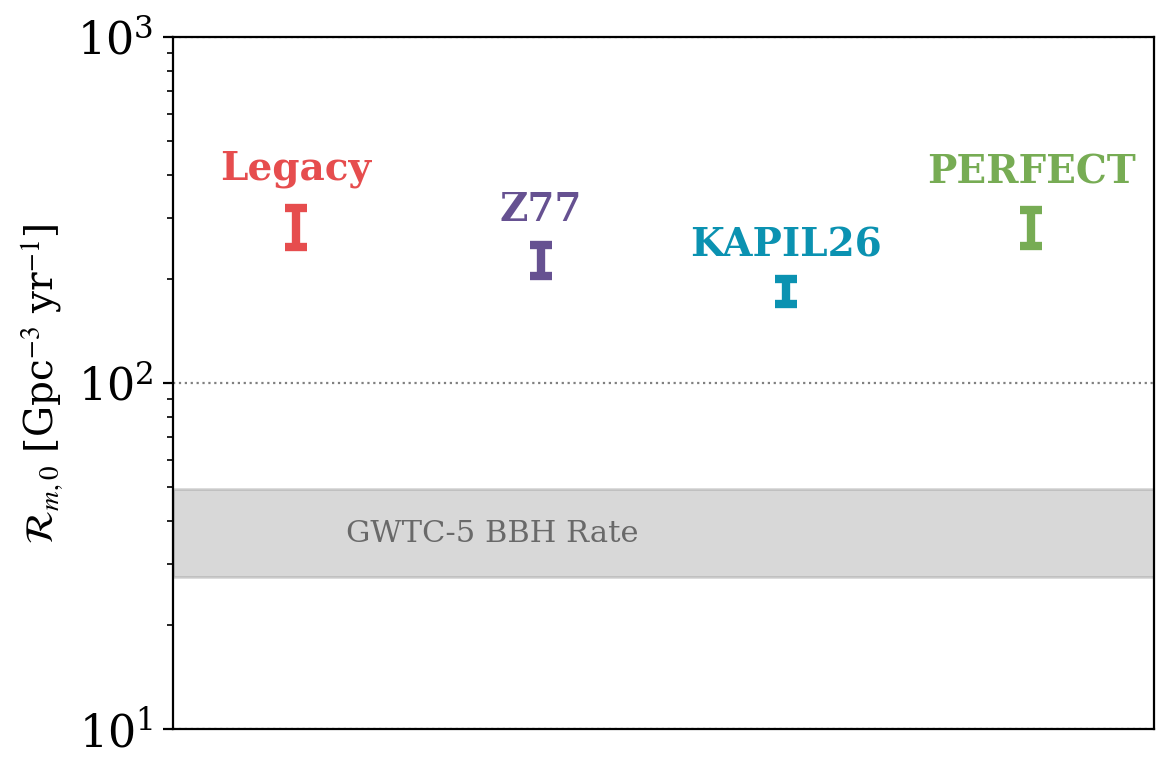

In [39]:
pop_labels = ['Legacy', 'Z77', 'KAPIL26', 'PERFECT']
local_rate_means = [2.84e+02, 2.27e+02 , 1.85e+02, 2.83e+02]
local_rate_2_sig = [3.68e+01, 2.33e+01, 1.56e+01, 3.40e+01]
ligo_rate_lims = [27.5, 49.4]

colors = [colorPalette['red'], colorPalette['violet'], colorPalette['blue'], colorPalette['green']]

fig, ax = plt.subplots(figsize=(6, 4))

# LVK shaded region
ax.axhspan(ligo_rate_lims[0], ligo_rate_lims[1], color='gray', alpha=0.3, label='GWTC-5 BBH Rate')
ax.text(
    1.4, np.sqrt(ligo_rate_lims[0] * ligo_rate_lims[1]),  # x near right edge, y centred in band
    'GWTC-5 BBH Rate',
    ha='right', va='center', fontsize=11, color='dimgray',
)


# Plot each point separately as an unconnected error bar
for i, (label, mean, err, color) in enumerate(zip(pop_labels, local_rate_means, local_rate_2_sig, colors)):
    ax.errorbar(
        label, mean, yerr=err,
        fmt='o',           # circle marker, no connecting line
        color=color,
        markersize=1,
        capsize=4,
        capthick=3,
        elinewidth=3,
        label=label,
        zorder=5,
    )

    ax.text(
        i, mean + err * 2.25,
        label,
        ha='center', va='bottom', fontsize=14, color=color, fontweight='bold',
    )

ax.set_ylabel(r'$\mathcal{R}_{m, 0}$ [Gpc$^{-3}$ yr$^{-1}$]', fontsize=14)
# ax.set_title('Local Merger Rate Density', fontsize=14)
# ax.legend(fontsize=15)
ax.grid(axis='y')
ax.set_ylim(1e1, 1e3)
ax.set_xlim(-0.5, 3.5)
ax.set_yscale('log')
ax.set_xticks([])          # remove x-axis ticks — labels are on the plot

plt.tight_layout()
plt.show()

# Figure 16 (Appendix B)

In [ ]:
plot_path = 'pop_plots/'
data_path = 'data_files/'

pop_names_z77 = ['realistic', 'z77']

pop_labels = {'notides': 'legacy', 'realistic': 'kapil26', 'perfect': 'perfect', 'z77': 'z77'}

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'perfect': colorPalette['green'],
             'z77': colorPalette['orange']}

In [ ]:
pop_rates_z77 = {}
pop_dfs_z77 = {}

for pop_name in pop_names_z77:
    pop_label = pop_labels[pop_name]
    pop_df = pd.read_csv(data_path + pop_name+'_spin_df.csv') 

    df = pop_df.copy()
    df = df[(df['BBH'] == True)]
    df['t_delay'] = df['Time@DCO'] + df['Coalescence_Time'] 
    # df = df[df['Merges_Hubble_Time']]


    any_rlof = (df['RLOF_Primary']==True) + (df['RLOF_Secondary']==True) + (df['RLOF_Both']==True)
    any_ce = (df['CE_Primary']==True) + (df['CE_Secondary']==True) +(df['CE_Both']==True)
    any_che = (df['CH_on_MS(1)']==True) + (df['CH_on_MS(2)']==True)

    smt = any_rlof * (~any_ce) * (~any_che)


    df['formation_channel'] = 0 # None
    df.loc[smt, 'formation_channel'] = 1 # SMT
    df.loc[any_ce, 'formation_channel'] = 2 # CE
    df.loc[any_che, 'formation_channel'] = 3 # CHE

    df = df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Metallicity@ZAMS(1)', 'Mass@DCO(1)', 'Mass@DCO(2)', 'chi_eff', 't_delay', 'formation_channel', 'CE_Both', 'a1', 'a2', 'fallback_1', 'fallback_2', 'iota1', 'iota2', 'SemiMajorAxis@DCO', 'Eccentricity@DCO', 'Merges_Hubble_Time', 'Time@DCO', 'Coalescence_Time']]
    pop_dfs_z77[pop_name] = df.copy() # Store the processed DataFrame for later use

    # Get weights from function above
    sfr, logZ_vec, z_weight_matrix = get_z_weights_matlab_style(
        z_merger_grid, df['Metallicity@ZAMS(1)'].min(), df['Metallicity@ZAMS(1)'].max()
    )

    # Initialize Rates [N_redshifts x N_binaries]
    rates = np.zeros((len(z_merger_grid), len(df)))


    print(f"Calculating rates for {pop_label} population with {len(df)} binaries...")
    for i in range(len(df)):
        z_binary = df['Metallicity@ZAMS(1)'].values[i]
        t_delay = df['t_delay'].values[i]
        
        # 1. Find the metallicity index in the weight matrix
        z_idx = np.argmin(np.abs(np.exp(logZ_vec) - z_binary))
        
        # 2. Formation lookback time for all possible merger times
        t_form = t_lookback + t_delay
        
        # 3. Valid indices where formation happens within our z_grid
        valid = t_form <= np.max(t_lookback)
        
        if np.any(valid):
            # Find formation redshifts
            z_form = t_to_z(t_form[valid])
            
            # We need to find which index in z_merger_grid corresponds to z_form
            # To match MATLAB's 'transpose(SFR(zFormindex))', we interpolate the weight 
            # specifically for this binary's metallicity across redshifts
            binary_z_weight_func = interp1d(z_merger_grid, z_weight_matrix[z_idx, :], fill_value="extrapolate")
            sfr_func = interp1d(z_merger_grid, sfr, fill_value="extrapolate")
            
            # Calculate the rate for this binary at every merger redshift
            # Rate = SFR(z_form) * Weight(z_form, Z_bin) / M_sim
            bin_rate = (sfr_func(z_form) * binary_z_weight_func(z_form)) / M_simulated
            
            rates[valid, i] = bin_rate
    
    pop_rates_z77[pop_name] = rates.sum(axis=0) # Total rate per binary integrated over redshift

Calculating rates for kapil26 population with 130751 binaries...
Calculating rates for z77 population with 132231 binaries...


realistic
z77


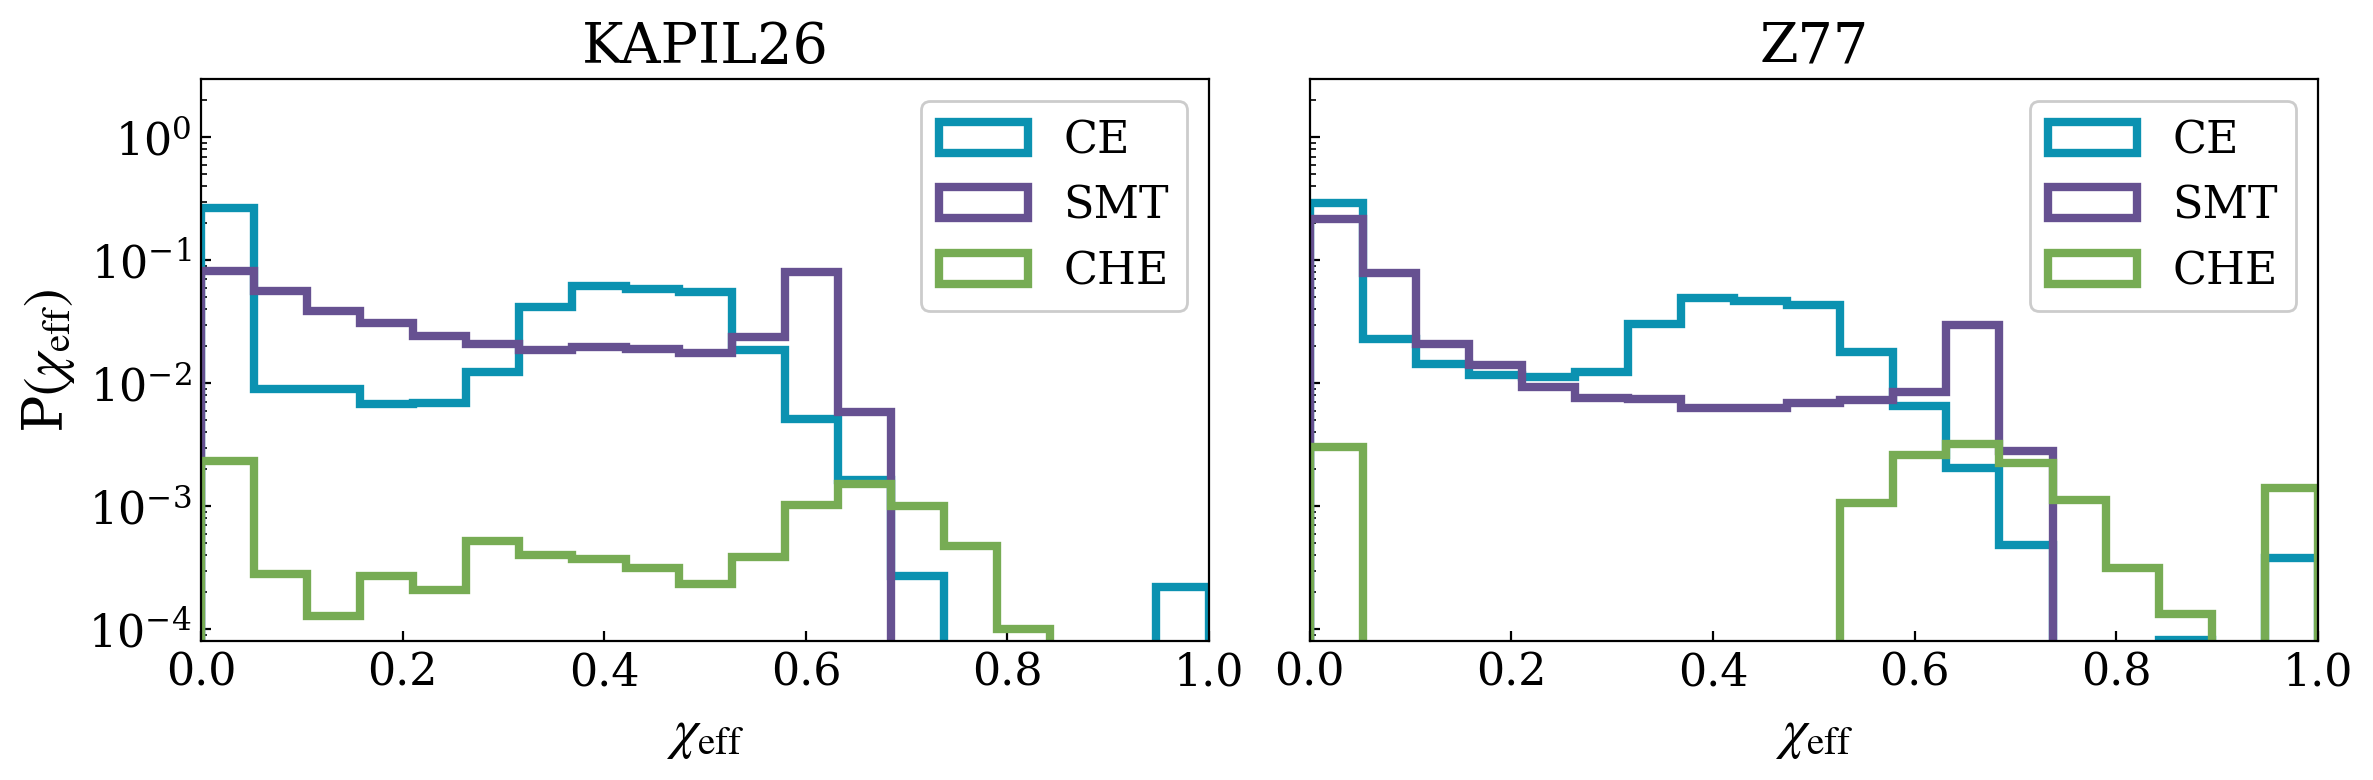

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=True)

for ax, pop_name in zip(axes, pop_names_z77):
    print(pop_name)
    pop_df = pop_dfs_z77[pop_name]
    merger_mask = (pop_df['Merges_Hubble_Time'] == True)
    pop_df = pop_df[merger_mask]

    total_weights = pop_rates_z77[pop_name][merger_mask]
    weight_norm = np.sum(total_weights)

    channels = {
        'CE':  (pop_df['formation_channel'] == 2, colorPalette['blue']),
        'SMT': (pop_df['formation_channel'] == 1, colorPalette['violet']),
        'CHE': (pop_df['formation_channel'] == 3, colorPalette['green']),
    }

    chi_grid = np.linspace(0, 1, 20)

    for label, (mask, color) in channels.items():
        w = total_weights[mask]
        chi = pop_df['chi_eff'].values[mask]

        if len(chi) > 0 and w.sum() > 0:
            ax.hist(chi, weights=w / weight_norm, bins=chi_grid, density=False, histtype='step', color=color, alpha=1, linewidth=3, label=label)

    ax.set_xlabel(r'$\chi_{\rm eff}$', fontsize=20)
    ax.set_xlim(0.0, 1)
    ax.set_ylim(0.8e-4, 3e0)
    ax.set_xticks(np.arange(0, 1.1, 0.2), minor=True)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=16)
    ax.set_yscale('log')

    ax.set_title(f'{pop_labels[pop_name].upper()}', fontsize=20)

    ax.legend(fontsize=16, loc='upper right')
    # ax.grid()
axes[0].set_ylabel(r'P$(\chi_{\rm eff})$', fontsize=20)
# plt.subplots_adjust(wspace=0.1, hspace=0)
plt.tight_layout()
# plt.savefig(plot_path + 'chi_eff_comparison_breakdown_z77.pdf', dpi=300, bbox_inches='tight')
plt.show()